In [83]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

In [84]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
features = pd.read_csv('/content/drive/MyDrive/datasettu/features_wm.csv')
sample = pd.read_csv('/content/drive/MyDrive/datasettu/sampleSubmission_wm.csv')
stores = pd.read_csv('/content/drive/MyDrive/datasettu/stores_wm.csv')
train = pd.read_csv('/content/drive/MyDrive/datasettu/train_wm.csv')
test = pd.read_csv('/content/drive/MyDrive/datasettu/test_wm.csv')

In [86]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [87]:
features.shape


(8190, 12)

In [88]:
sample.head()

,Id,Weekly_Sales
0,1_1_2012-11-02,0
1,1_1_2012-11-09,0
2,1_1_2012-11-16,0
3,1_1_2012-11-23,0
4,1_1_2012-11-30,0


In [89]:
sample.shape

(115064, 2)

In [90]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [91]:
stores.shape



(45, 3)

In [92]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [93]:
feature_store = features.merge(stores, how="inner", on = "Store").copy()

In [94]:
feature_store.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [95]:
train_df = train.merge(feature_store, how="inner", on=['Store', 'Date', 'IsHoliday'])\
    .sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True).copy()

In [96]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [97]:
test_df = test.merge(feature_store, how="inner", on=['Store', 'Date', 'IsHoliday'])\
    .sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True).copy()

In [98]:
test_df.head()

,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2012-11-02,False,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,A,151315
1,1,1,2012-11-09,False,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,A,151315
2,1,1,2012-11-16,False,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,A,151315
3,1,1,2012-11-23,True,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,A,151315
4,1,1,2012-11-30,False,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,A,151315


In [99]:
train_df.describe()

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
std,12.785297,30.492054,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000


In [100]:
train_df.dtypes

,0
Store,int64
Dept,int64
Date,object
Weekly_Sales,float64
IsHoliday,bool
Temperature,float64
Fuel_Price,float64
MarkDown1,float64
MarkDown2,float64
MarkDown3,float64


In [101]:
feature_store['Date'] = pd.to_datetime(feature_store['Date'])
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])

In [102]:
feature_store['Day'] = feature_store['Date'].dt.isocalendar().day
feature_store['Week'] = feature_store['Date'].dt.isocalendar().week
feature_store['Month'] = feature_store['Date'].dt.month
feature_store['Year'] = feature_store['Date'].dt.isocalendar().year

In [103]:
feature_store.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size,Day,Week,Month,Year
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315,5,5,2,2010
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315,5,6,2,2010
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315,5,7,2,2010
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315,5,8,2,2010
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315,5,9,3,2010


In [104]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [105]:
train_df = train.merge(feature_store, how='inner', on = ['Store','Date','IsHoliday'])\
    .sort_values(by=['Store','Dept','Date']).reset_index(drop=True).copy()
test_df = test.merge(feature_store, how='inner', on = ['Store','Date','IsHoliday'])\
    .sort_values(by=['Store','Dept','Date']).reset_index(drop=True).copy()

In [106]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Day,Week,Month,Year
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315,5,5,2,2010
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315,5,6,2,2010
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315,5,7,2,2010
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315,5,8,2,2010
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315,5,9,3,2010


In [107]:
df_weeks = train_df.groupby("Week").sum(numeric_only=True)


In [108]:
df_weeks.head()

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Day,Month,Year
Week,,,,,,,,,,,,,,,,,
1,130899,260501,8.773121e+07,0,222343.25,18872.529,1.499397e+07,67007392.71,353486.72,3078155.61,15506769.87,1.008962e+06,46396.361,806775433,29515,5903,11873906
2,131036,260045,8.269676e+07,0,204005.74,19098.337,1.019858e+07,29235314.34,218513.27,1565390.83,11416226.10,1.007821e+06,46330.934,805424262,29470,5894,11855800
3,130031,259381,8.273564e+07,0,222547.92,19167.202,7.210967e+06,9824350.22,214079.04,1942054.54,8410008.53,1.006852e+06,46151.605,804330161,29385,5877,11821606
4,129971,259111,7.943483e+07,0,221326.56,19229.283,4.418107e+06,5170160.65,213215.80,296603.35,7927497.89,1.006330e+06,46135.250,803454747,29355,5871,11809533
5,195904,392036,1.419895e+08,0,317172.19,27489.729,1.140734e+08,8936033.33,448553.25,90821661.61,18580144.27,1.507341e+06,71739.976,1213767653,44290,17716,17813460


In [109]:
px.line(data_frame=df_weeks, x=df_weeks.index, y="Weekly_Sales",
       title="Weekly Sales vs. Weeks")

In [110]:
fig = go.Figure()
fig.add_trace(go.Scatter(x = df_weeks.index,
                         y=df_weeks['MarkDown1'],
                         name='MarkDown1',
                         mode='lines'))
fig.add_trace(go.Scatter(x = df_weeks.index,
                         y=df_weeks['MarkDown2'],
                         name='MarkDown2',
                         mode='lines'))
fig.add_trace(go.Scatter(x = df_weeks.index,
                         y=df_weeks['MarkDown3'],
                         name='MarkDown3',
                         mode='lines'))
fig.add_trace(go.Scatter(x = df_weeks.index,
                         y=df_weeks['MarkDown4'],
                         name='MarkDown4',
                         mode='lines'))
fig.add_trace(go.Scatter(x = df_weeks.index,
                         y=df_weeks['MarkDown5'],
                         name='MarkDown5',
                         mode='lines'))
fig.add_trace(go.Scatter(x = df_weeks.index,
                         y=df_weeks['Weekly_Sales'],
                         name='Weekly_Sales',
                         mode='lines'))
fig.update_layout(title="Sales vs. Markdowns", xaxis_title="Weeks")

In [111]:
## Mean sales across years (Highest for Weekly Sales after 50 weeks)

In [112]:
# Weekly Sales per Year with Week

weekly_sales_by_week = train_df.groupby(by=["Year", "Week"], as_index=False).agg({"Weekly_Sales" : ["mean", "median"]}).copy()
weekly_sales_by_week_2010 = weekly_sales_by_week.loc[weekly_sales_by_week["Year"] == 2010].copy()
weekly_sales_by_week_2011 = weekly_sales_by_week.loc[weekly_sales_by_week["Year"] == 2011].copy()
weekly_sales_by_week_2012 = weekly_sales_by_week.loc[weekly_sales_by_week["Year"] == 2012].copy()

weekly_sales_by_week_2010 = weekly_sales_by_week_2010.reset_index(drop=True)
weekly_sales_by_week_2011 = weekly_sales_by_week_2011.reset_index(drop=True)
weekly_sales_by_week_2012 = weekly_sales_by_week_2012.reset_index(drop=True)

weekly_sales_by_week = pd.concat([weekly_sales_by_week_2010, weekly_sales_by_week_2011, weekly_sales_by_week_2012], axis=1)
weekly_sales_by_week.head()

Year Week  Weekly_Sales            Year Week  Weekly_Sales            Year  \
                      mean    median                     mean    median         
0  2010    5  16836.121997  7904.690  2011    1  14599.244973  6384.990  2012   
1  2010    6  16352.056032  8365.095  2011    2  13891.283484  5961.710  2012   
2  2010    7  16216.658979  8411.250  2011    3  13932.367385  6139.315  2012   
3  2010    8  14899.549688  7235.800  2011    4  13566.239462  6227.980  2012   
4  2010    9  15921.015727  7717.975  2011    5  15773.448776  7312.115  2012   

  Week  Weekly_Sales           
                mean   median  
0    1  15121.231736  6586.37  
1    2  14168.266514  5914.86  
2    3  14221.357405  6146.31  
3    4  13494.232612  5785.84  
4    5  15480.553608  6859.65

In [113]:
# Weekly Sales per Year

weekly_sales_by_year = train_df.groupby(by=["Year"], as_index=False).agg({"Weekly_Sales" : ["mean", "median"]}).copy()

weekly_sales_by_year_2010 = weekly_sales_by_year.loc[weekly_sales_by_year["Year"] == 2010].copy()
weekly_sales_by_year_2011 = weekly_sales_by_year.loc[weekly_sales_by_year["Year"] == 2011].copy()
weekly_sales_by_year_2012 = weekly_sales_by_year.loc[weekly_sales_by_year["Year"] == 2012].copy()

weekly_sales_by_year_2010 = weekly_sales_by_year_2010.reset_index(drop=True)
weekly_sales_by_year_2011 = weekly_sales_by_year_2011.reset_index(drop=True)
weekly_sales_by_year_2012 = weekly_sales_by_year_2012.reset_index(drop=True)

weekly_sales_by_year = pd.concat([weekly_sales_by_year_2010, weekly_sales_by_year_2011, weekly_sales_by_year_2012], axis=0)
weekly_sales_by_year.head()

Year  Weekly_Sales          
                 mean    median
0  2010  16270.275737  7964.300
0  2011  15954.070675  7522.020
0  2012  15694.948597  7365.095

In [114]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=weekly_sales_by_week_2010.index,
                     y=weekly_sales_by_week_2010["Weekly_Sales"]["mean"],
                     name="2010",
                     mode="lines"))
fig.add_trace(go.Scatter(x=weekly_sales_by_week_2011.index,
                     y=weekly_sales_by_week_2011["Weekly_Sales"]["mean"],
                     name="2011",
                     mode="lines"))
fig.add_trace(go.Scatter(x=weekly_sales_by_week_2012.index,
                     y=weekly_sales_by_week_2012["Weekly_Sales"]["mean"],
                     name="2012",
                     mode="lines"))

In [115]:
## Clearly there is an increase of sales at the end of the year.
## Reasons could be anything like year end sales, special offers and discounts during that period, etc.

In [116]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Day,Week,Month,Year
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315,5,5,2,2010
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315,5,6,2,2010
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315,5,7,2,2010
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315,5,8,2,2010
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315,5,9,3,2010


<Axes: >

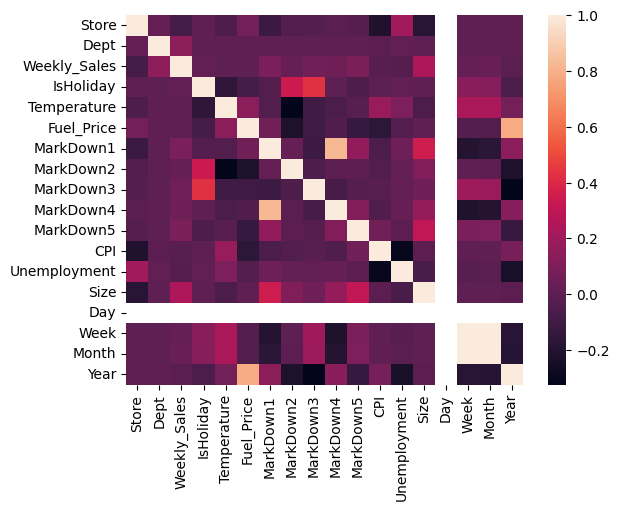

In [117]:
corr = train_df.corr(numeric_only=True)
corr
sns.heatmap(corr)

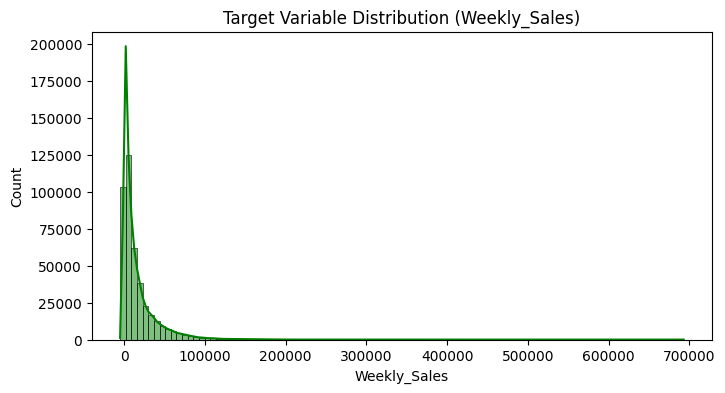

In [118]:
#Let us first analyze the distribution of the target variable

plt.figure(figsize=[8,4])
sns.histplot(train_df['Weekly_Sales'], color='g',kde=True, bins=100)
plt.title('Target Variable Distribution (Weekly_Sales)')
plt.show()

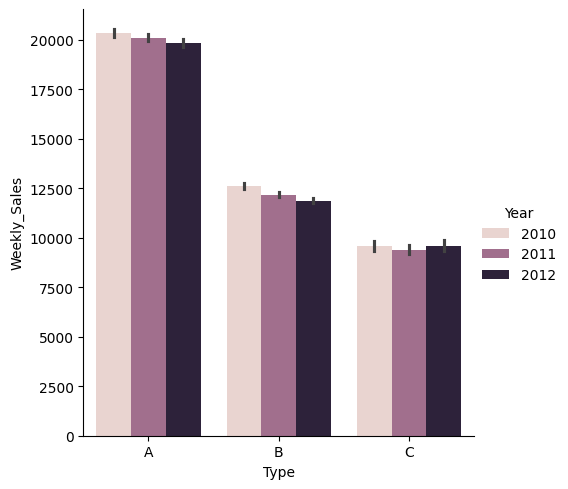

In [119]:
## As you can see, our target variable is right skewed/ positively skewed, i.e., here Mean > Mode > Median
# Understanding 'Type' column for each year

sns.catplot(data=train_df, x="Type", y="Weekly_Sales", hue="Year", kind="bar")

<Figure size 1200x500 with 0 Axes>

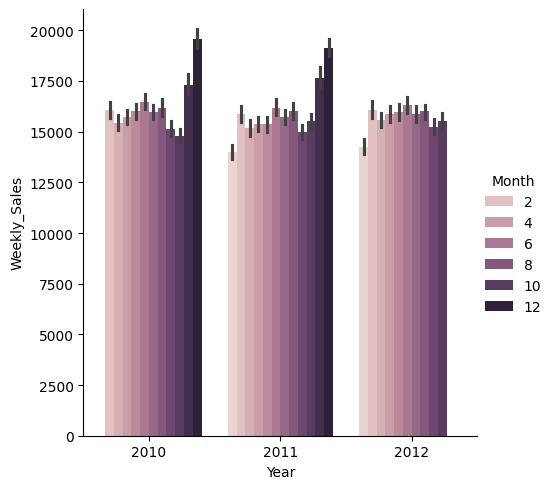

In [120]:
# Understanding month-wise sales for every year

plt.figure(figsize=[12,5])
sns.catplot(data=train_df, x="Year", y="Weekly_Sales", hue="Month", kind="bar")
plt.show()

In [121]:
## It seems like for year 2010 and 2011, month end sales (November & December) were high, however same was not seen for the year 2012.
train_df.dtypes

,0
Store,int64
Dept,int64
Date,datetime64[ns]
Weekly_Sales,float64
IsHoliday,bool
Temperature,float64
Fuel_Price,float64
MarkDown1,float64
MarkDown2,float64
MarkDown3,float64


In [122]:

# Making categorical columns and numerical columns in separate lists

nf=[]
cf = ['Date', 'Store', 'Dept', 'IsHoliday', 'Type', 'Day', 'Month', 'Year']
for i in train_df.columns:
  if i not in cf:
    nf.append(i)
print(nf)

['Weekly_Sales', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Week']


                                                Numeric Features Distribution                                                 


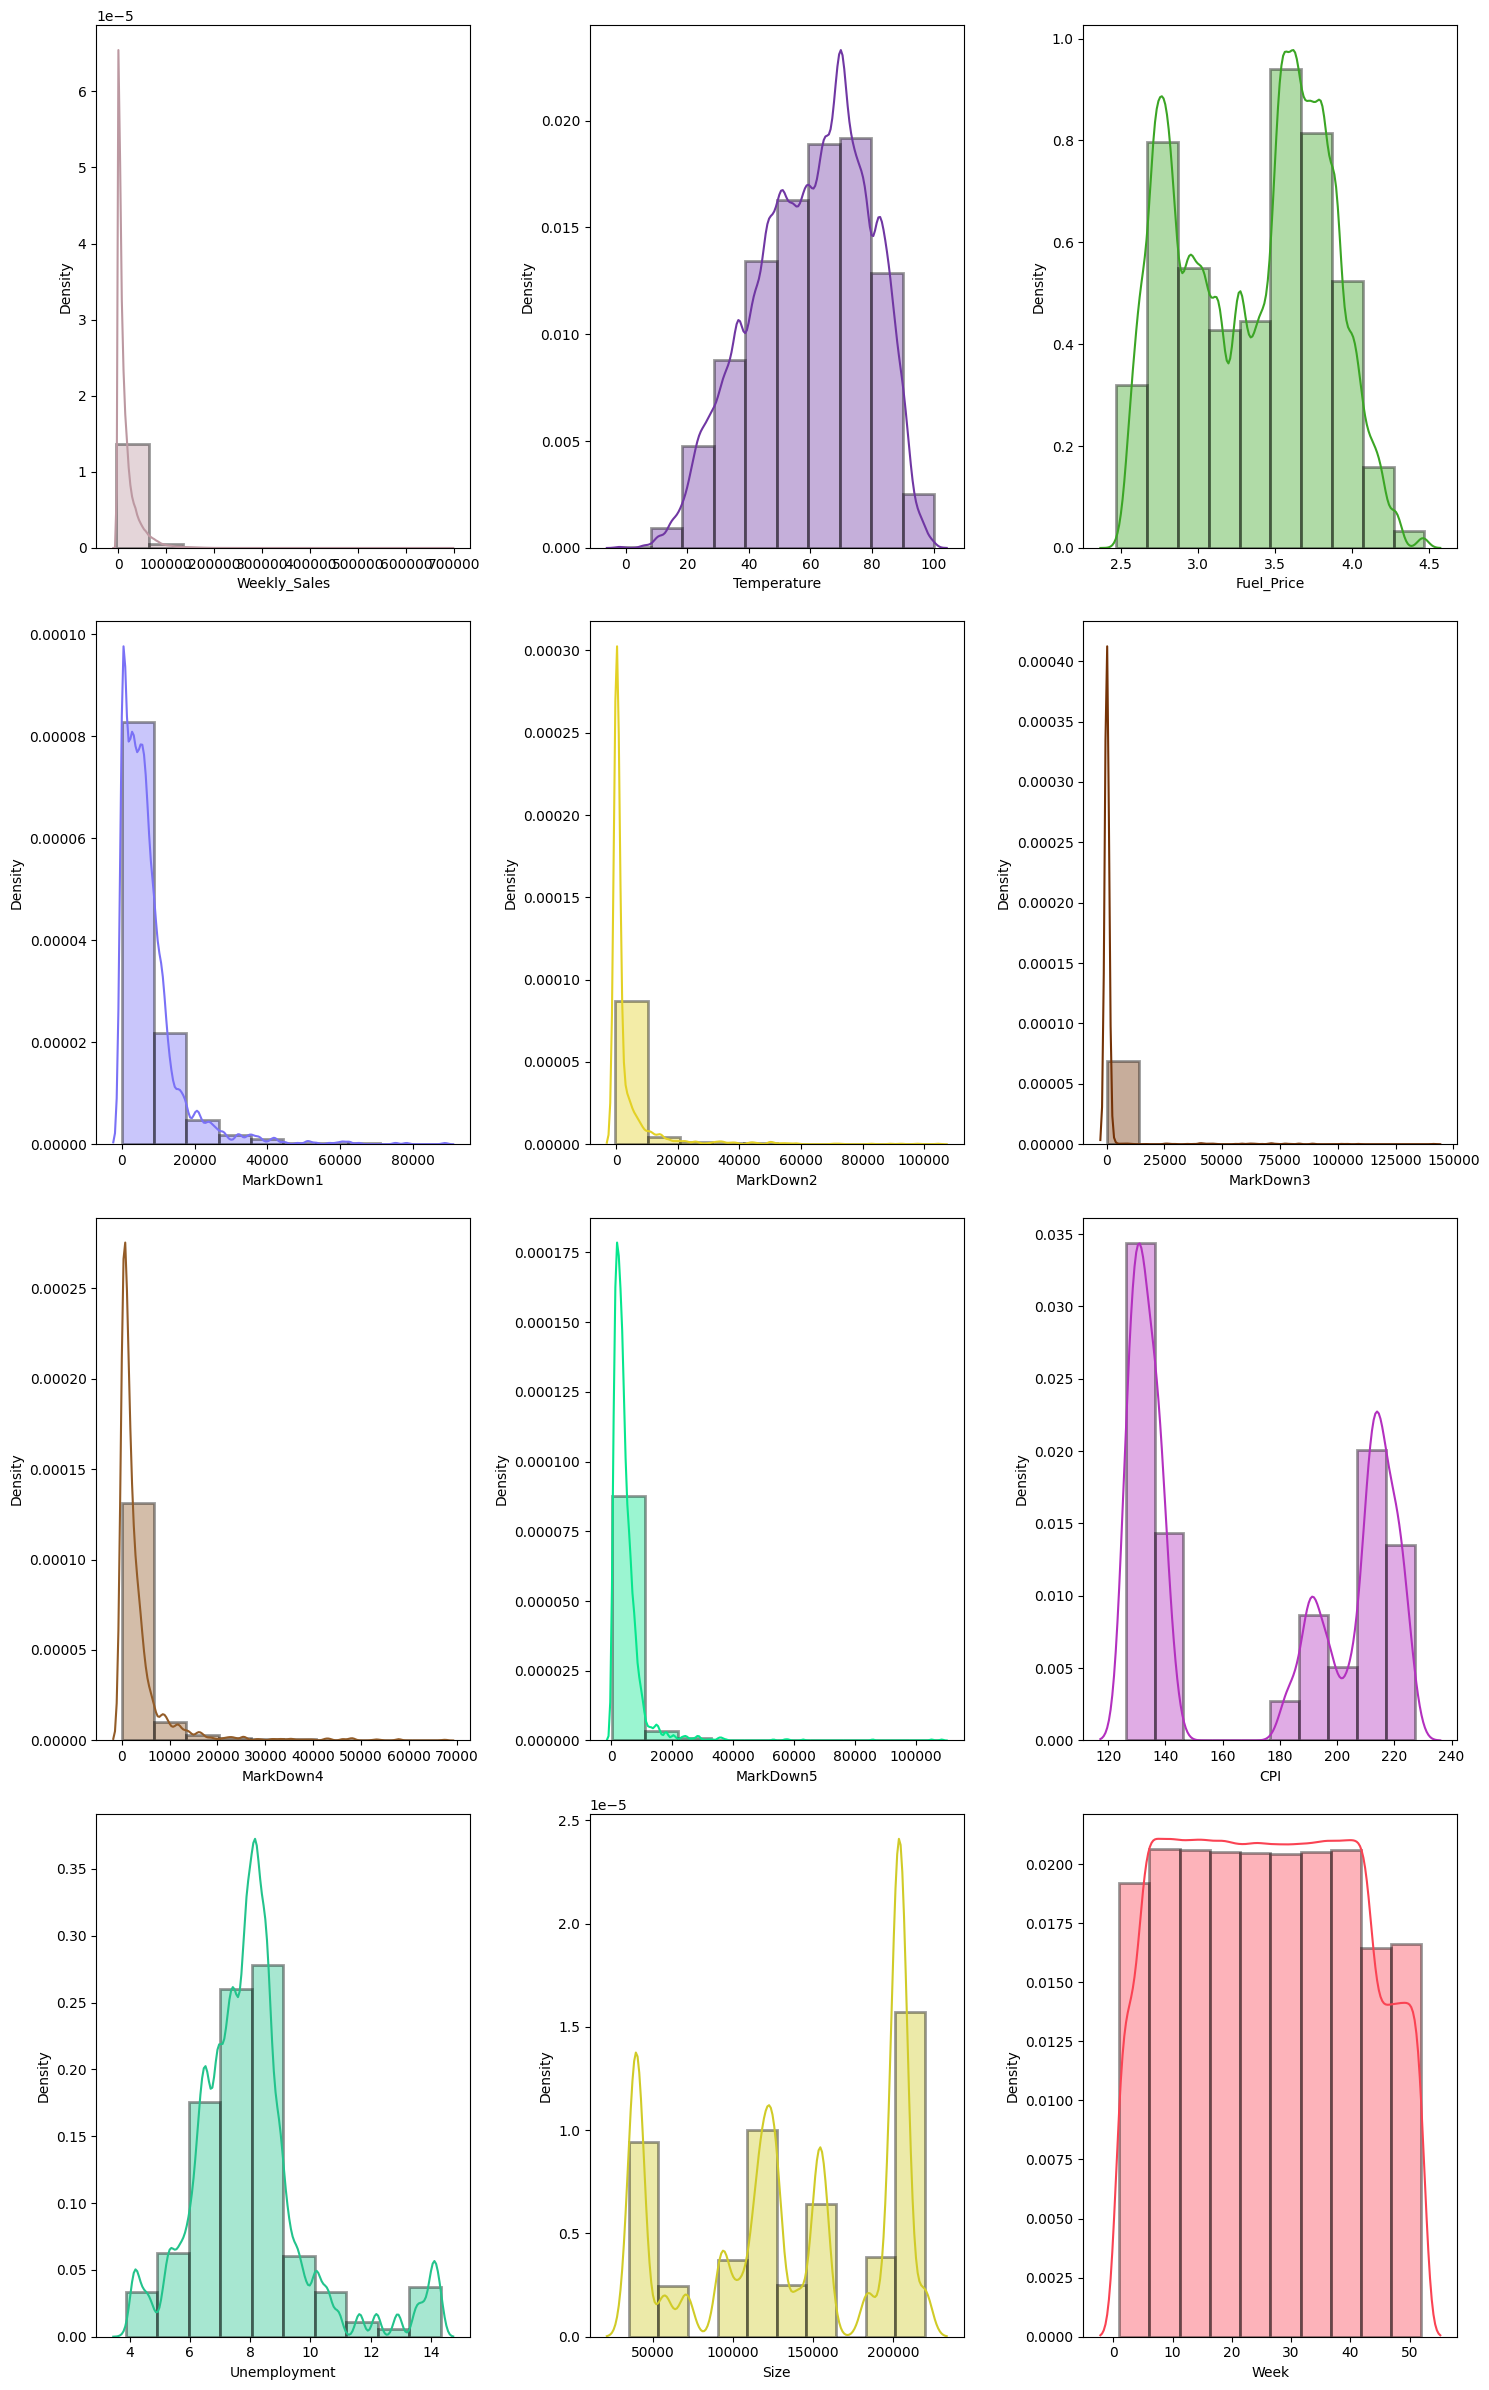

'\nplt.figure(figsize=[15,6*math.ceil(len(nf)/n)])\nfor i in range(len(nf)):\n    plt.subplot(math.ceil(len(nf)/3),n,i+1)\n    train_df.boxplot(nf[i])\nplt.tight_layout()\nplt.show()\n'

In [123]:
#Visualising the numeric features

print('\033[1mNumeric Features Distribution'.center(130))

n=3

clr=['r','g','b','g','b','r']

plt.figure(figsize=[15,6*math.ceil(len(nf)/n)])
for i in range(len(nf)):
    plt.subplot(math.ceil(len(nf)/3),n,i+1)
    sns.distplot(train_df[nf[i]],hist_kws=dict(edgecolor="black", linewidth=2), bins=10, color=list(np.random.randint([255,255,255])/255))
plt.tight_layout()
plt.show()

'''
plt.figure(figsize=[15,6*math.ceil(len(nf)/n)])
for i in range(len(nf)):
    plt.subplot(math.ceil(len(nf)/3),n,i+1)
    train_df.boxplot(nf[i])
plt.tight_layout()
plt.show()
'''

<Axes: xlabel='Store', ylabel='Weekly_Sales'>

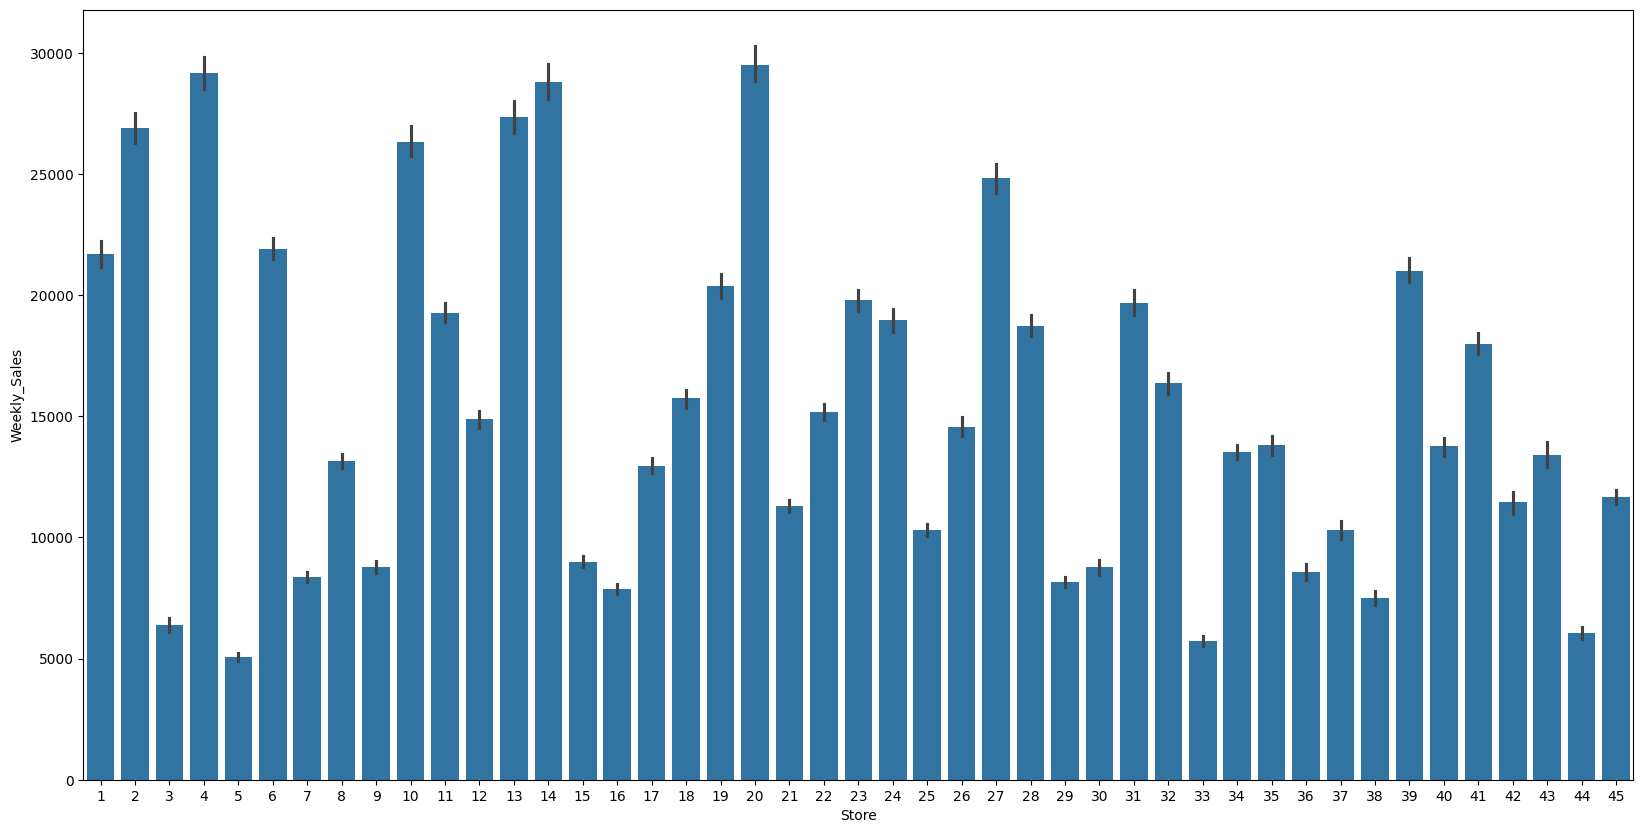

In [124]:
plt.figure(figsize=(20,10))
sns.barplot(x=train_df.Store, y = train_df.Weekly_Sales)

In [125]:
## Clearly after looking at the plot you can infer that the Store 20 has the maximum Weekly_Sales and Store 5 has the minimum Weekly_Sales.

<Axes: xlabel='Date', ylabel='Weekly_Sales'>

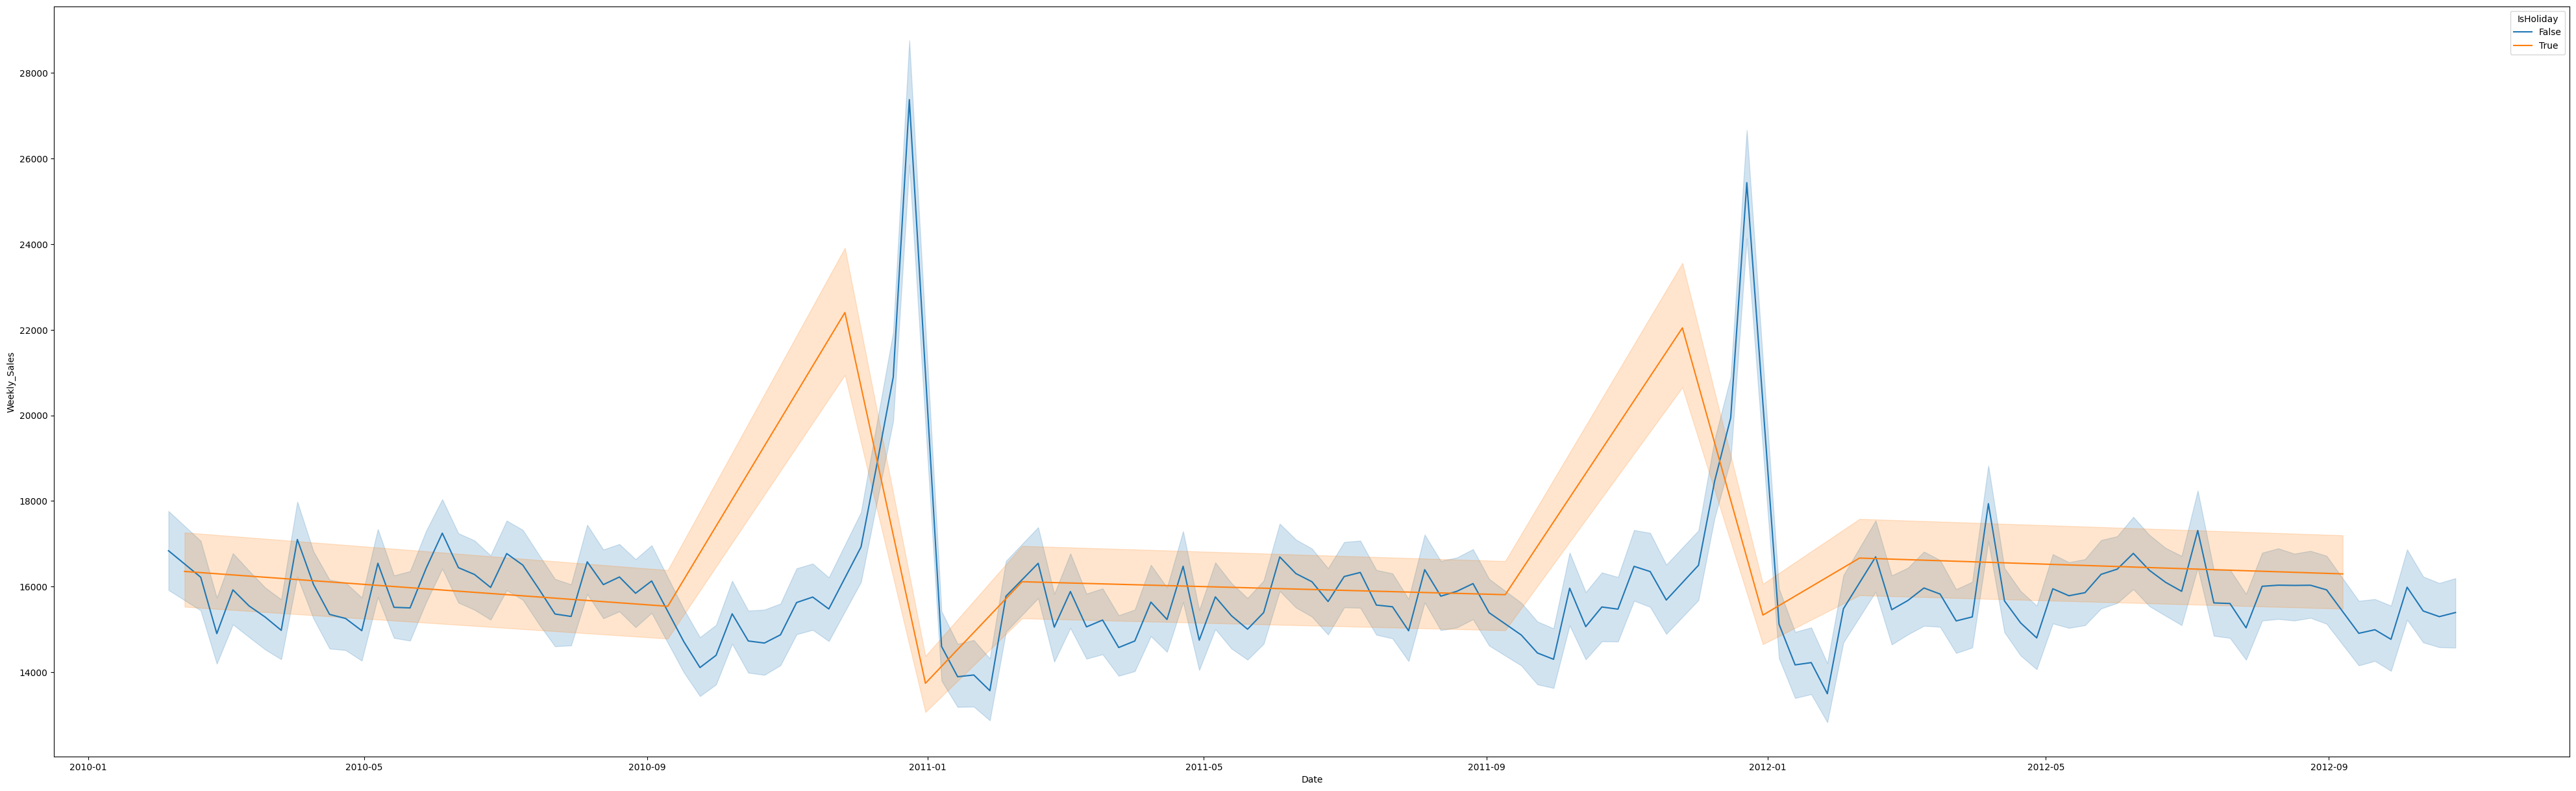

In [126]:
plt.figure(figsize=(50,15))
sns.lineplot(x='Date', y = 'Weekly_Sales', data = train_df, hue='IsHoliday')

In [127]:
## Also now if you look at this lineplot of Weekly_Sales for store 35 it is clear that how sales are varying with during a week of a year, which is highly variable. So you can say that there is very irregular sale pattern for store 35. During the holidays only it is seeing high amount of sales. So you can infer that the store 35 will be seeing high demands in products due sudden rise in sales during holiday seasons.

In [128]:
# Grouping Data by Year

growth = train_df.copy()
growth['Date'] = pd.to_datetime(growth.Date,format='%d-%m-%Y')
growth['Year'], growth['Month'] = growth['Date'].dt.year, growth['Date'].dt.month
growth

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Day,Week,Month,Year
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315,5,5,2,2010
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315,5,6,2,2010
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315,5,7,2,2010
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315,5,8,2,2010
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315,5,9,3,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221,5,39,9,2012
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,B,118221,5,40,10,2012
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,B,118221,5,41,10,2012
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,B,118221,5,42,10,2012


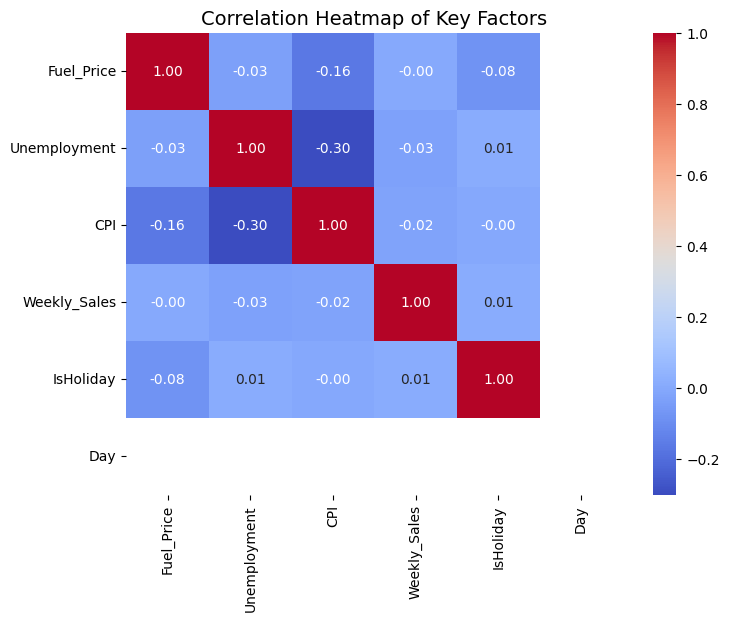

In [129]:
factors = train_df[["Fuel_Price", "Unemployment", "CPI",
                    "Weekly_Sales", "IsHoliday", "Day"]]

# Compute correlation
corr = factors.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Key Factors", fontsize=14)
plt.show()

In [130]:
## It seems like Unemployment column is negatively correlated with Fuel_Price and CPI column, whereas CPI and Fuel_Price is positively correlated.

In [131]:
#let's Group the data.

hypothesis = growth.groupby('Store')[['Fuel_Price','Unemployment', 'CPI','Weekly_Sales', 'IsHoliday']]
factors  = hypothesis.get_group(1)
day_arr = [1]
for i in range (1,len(factors)):
    day_arr.append(i*7)

factors['Day'] = day_arr.copy()

In [132]:
factors

,Fuel_Price,Unemployment,CPI,Weekly_Sales,IsHoliday,Day
0,2.572,8.106,211.096358,24924.50,False,1
1,2.548,8.106,211.242170,46039.49,True,7
2,2.514,8.106,211.289143,41595.55,False,14
3,2.561,8.106,211.319643,19403.54,False,21
4,2.625,8.106,211.350143,21827.90,False,28
...,...,...,...,...,...,...
10239,3.638,6.908,222.305480,20.06,False,71673
10240,3.730,6.908,222.439015,0.05,True,71680
10241,3.717,6.908,222.582019,0.03,False,71687
10242,3.617,6.573,223.181477,635.00,False,71694


Hypothesis Testing

0.0
reject null hypothesis


<Axes: xlabel='CPI', ylabel='Weekly_Sales'>

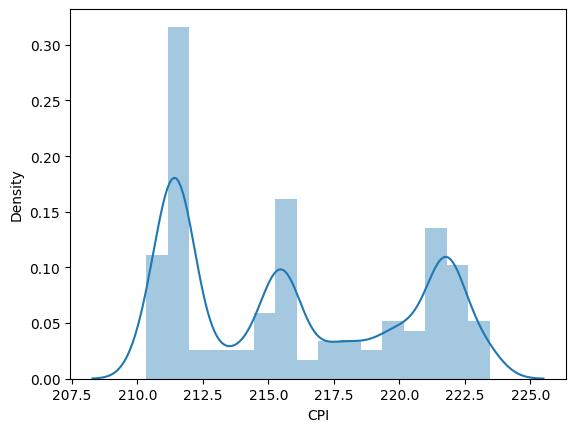

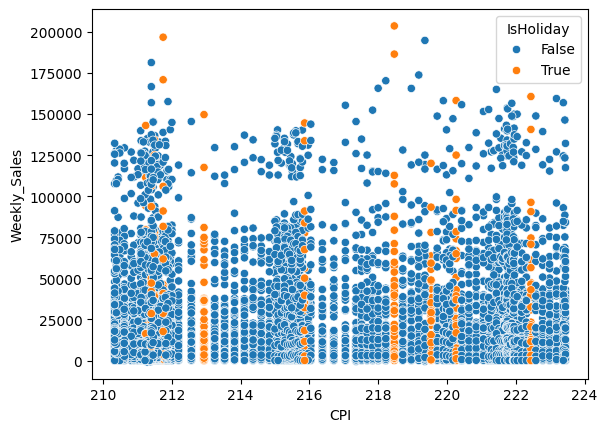

<Figure size 640x480 with 0 Axes>

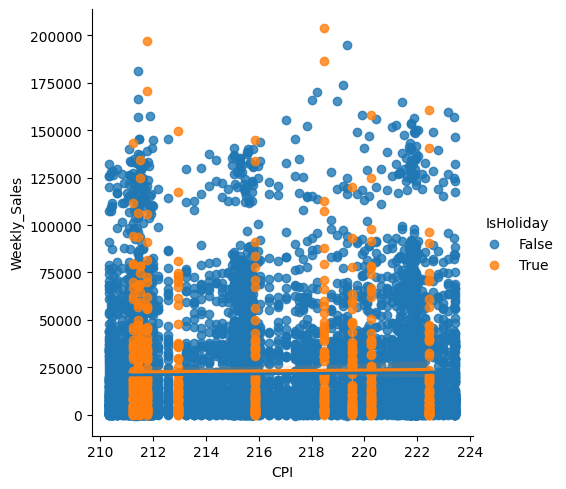

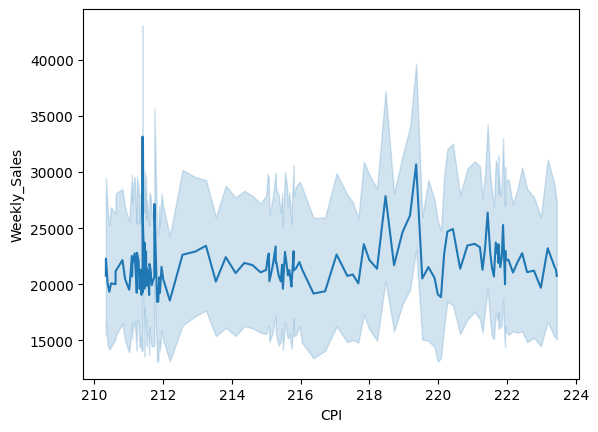

In [133]:
from scipy import stats
ttest,pval = stats.ttest_rel(factors['Weekly_Sales'],factors['CPI'])
sns.distplot(factors.CPI)
plt.figure()
print(pval)
if pval<0.05:
    print("reject null hypothesis")
else:
    print("accept null hypothesis")

sns.scatterplot(x='CPI', y = 'Weekly_Sales', data = factors, hue = 'IsHoliday')
plt.figure()
sns.lmplot(x='CPI', y = 'Weekly_Sales', data = factors, hue = 'IsHoliday')
plt.figure()
sns.lineplot(x='CPI', y = 'Weekly_Sales', data = factors)

In [134]:
#Analysis

#From the above plots, you can see how Weekly_Sales and CPI are correlated to each other. Also we rejected the null hypothesis saying that there is no relationship between Weekly_sales and CPI. But we found there is a positive corrlation between CPI and Weekly_sales, which we have found out by our statistical Modelling.

#Also, the CPI is not normally distributed and line regression plot is showing how CPI is varying with Weekly_Sales on days of Holidays and non holiday weeks.

0.0
reject null hypothesis


<Axes: xlabel='Fuel_Price', ylabel='Weekly_Sales'>

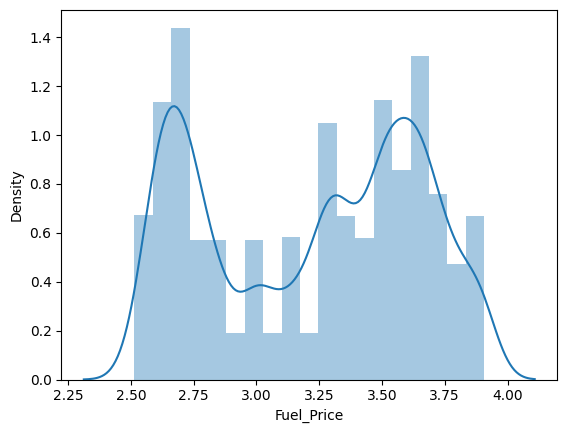

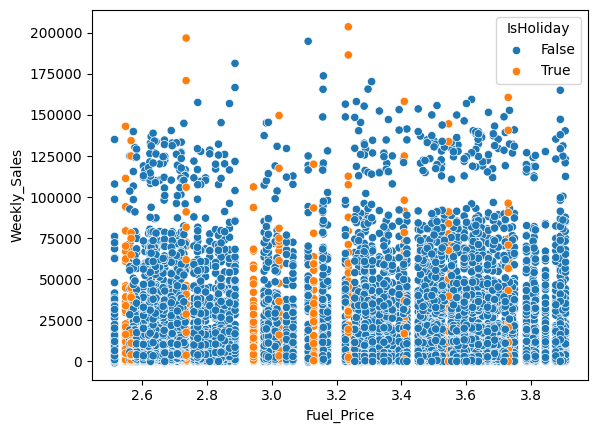

<Figure size 640x480 with 0 Axes>

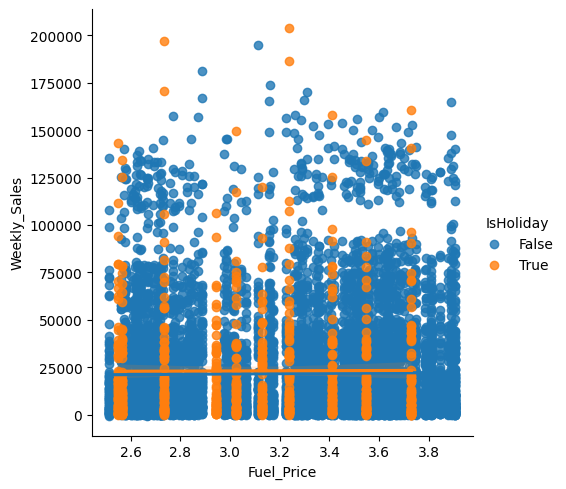

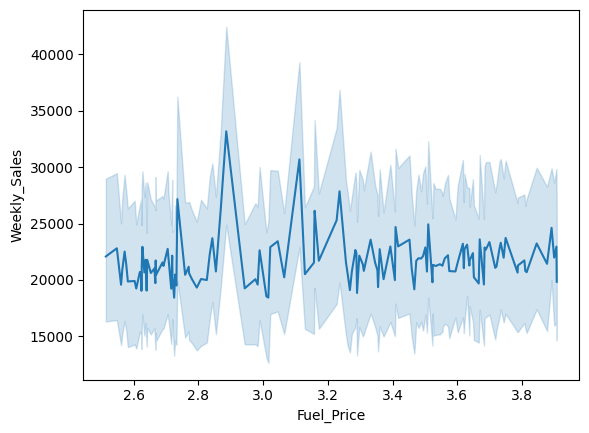

In [135]:
from scipy import stats
ttest,pval = stats.ttest_rel(factors['Weekly_Sales'],factors['Fuel_Price'])
sns.distplot(factors.Fuel_Price)
plt.figure()
print(pval)
if pval<0.05:
    print("reject null hypothesis")
else:
    print("accept null hypothesis")

sns.scatterplot(x='Fuel_Price', y = 'Weekly_Sales', data = factors, hue = 'IsHoliday')
plt.figure()
sns.lmplot(x='Fuel_Price', y = 'Weekly_Sales', data = factors, hue = 'IsHoliday')
plt.figure()
sns.lineplot(x='Fuel_Price', y = 'Weekly_Sales', data = factors)

0.0
reject null hypothesis


<Axes: xlabel='Unemployment', ylabel='Weekly_Sales'>

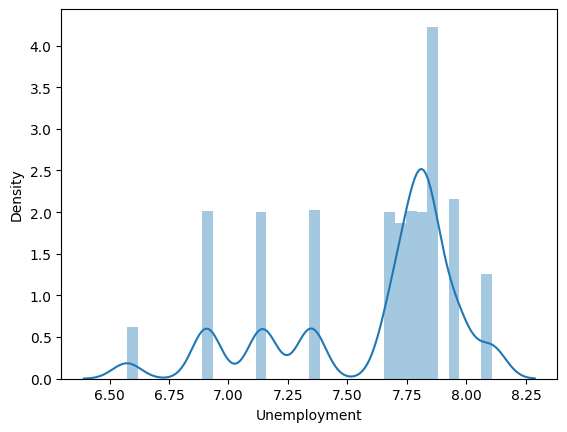

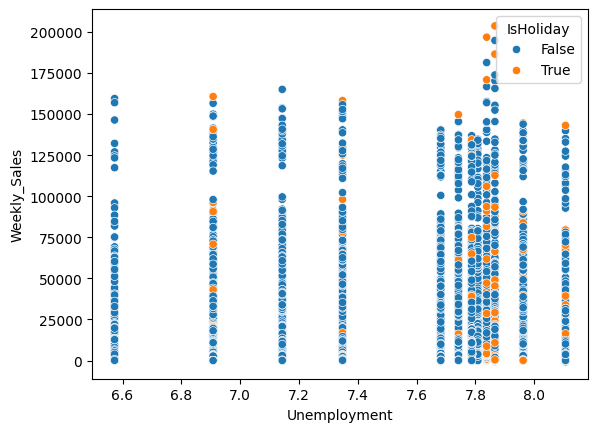

<Figure size 640x480 with 0 Axes>

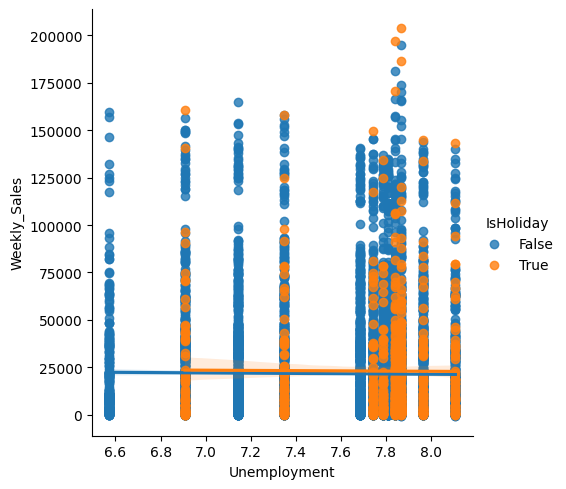

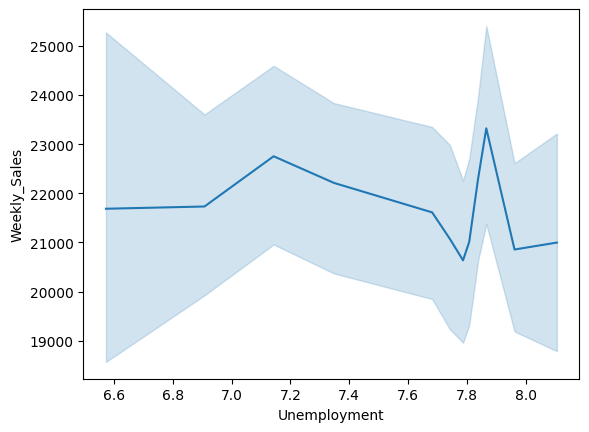

In [136]:
from scipy import stats
ttest,pval = stats.ttest_rel(factors['Weekly_Sales'],factors['Unemployment'])
sns.distplot(factors.Unemployment)
plt.figure()
print(pval)
if pval<0.05:
    print("reject null hypothesis")
else:
    print("accept null hypothesis")

sns.scatterplot(x='Unemployment', y = 'Weekly_Sales', data = factors, hue = 'IsHoliday')
plt.figure()
sns.lmplot(x='Unemployment', y = 'Weekly_Sales', data = factors, hue = 'IsHoliday')
plt.figure()
sns.lineplot(x='Unemployment', y = 'Weekly_Sales', data = factors)

In [137]:
#Analysis

#Plot 1 shows the distribution of Unemployment rate, whose mean is between 7.5 - 8.0, quite high.

#Plot 2 and Plot 3 shows how weekly_sales are impacted because of rate of Unemployment as you can see as the rate of unemployment incrreases people only buy during holiday seasons, as there are only few outliers present for weekly_sales and which are on the day of Holiday. Speaking of which people only buy necessary products and try to save more.

#Also we reject null hypothesis as weekly_sales and rate of unemployment are negatively correlated as suggested by our heatmap of the correlation. P value is less than alpha hence we reject null hypothesis and accept alterante hypothesis

In [138]:
### Plotting Weekly_sales day wise for store 1, by keeping holidays as a parameter to get more insights

<Axes: xlabel='Day', ylabel='Weekly_Sales'>

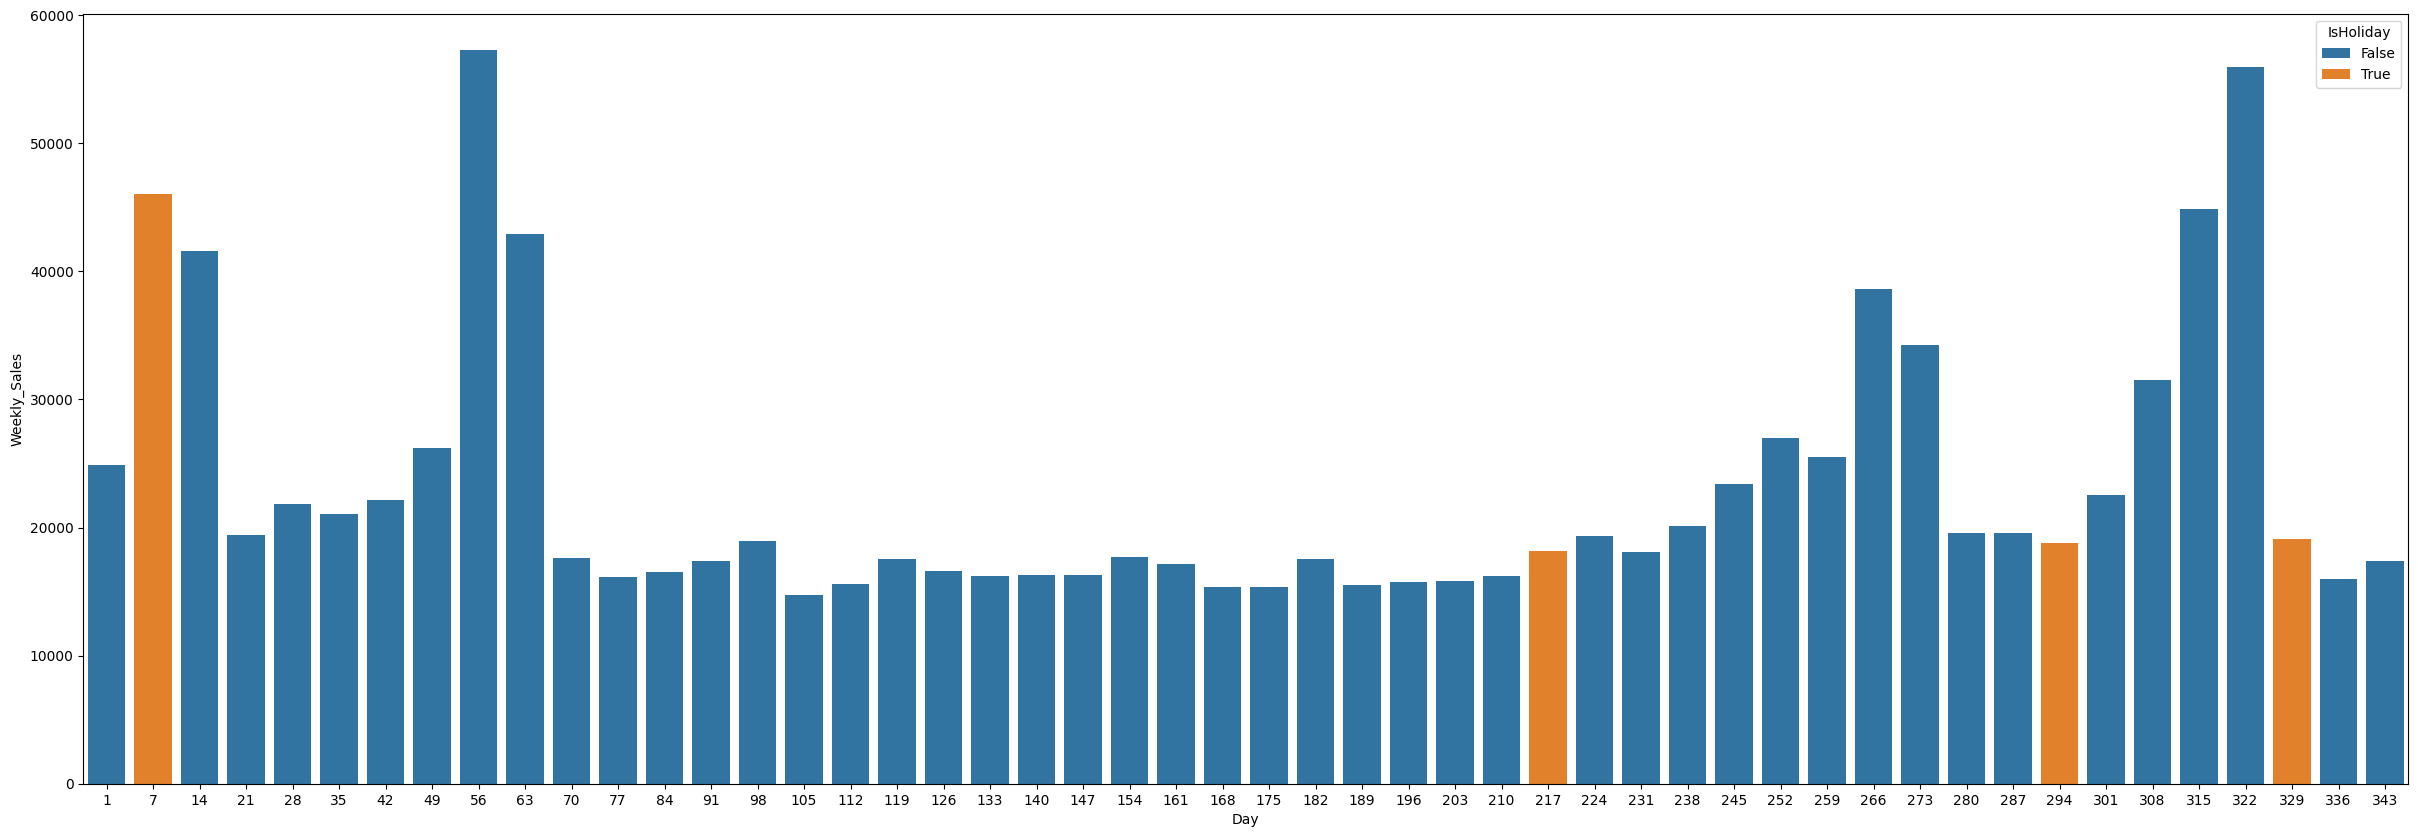

In [139]:
plt.figure(figsize=(30,10))
sns.barplot(x='Day', y = 'Weekly_Sales', data = factors.head(50), hue = 'IsHoliday')

Data Preprocessing

In [140]:
test_df.isna().sum()

,0
Store,0
Dept,0
Date,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,149
MarkDown2,28627
MarkDown3,9829
MarkDown4,12888


In [141]:
train_data = train_df.copy()
test_data = test_df.copy()
train_data.fillna(0, inplace=True)


In [142]:
train_data.isna().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0


In [143]:
test_data.isna().sum()

,0
Store,0
Dept,0
Date,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,149
MarkDown2,28627
MarkDown3,9829
MarkDown4,12888


In [144]:
test_data['CPI'].fillna(test_data['CPI'].mean(), inplace=True)
test_data['Unemployment'].fillna(test_data['Unemployment'].mean(), inplace=True)
test_data.fillna(0, inplace=True)

In [145]:
test_data.isna().sum()

,0
Store,0
Dept,0
Date,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0
MarkDown4,0


In [146]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_data['IsHoliday'] = le.fit_transform(train_data['IsHoliday'])
test_data['IsHoliday'] = le.fit_transform(test_data['IsHoliday'])
train_data.head()


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Day,Week,Month,Year
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,5,5,2,2010
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,5,6,2,2010
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,5,7,2,2010
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,5,8,2,2010
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,5,9,3,2010


In [147]:
train_data['Type'] = le.fit_transform(train_data['Type'])
test_data['Type'] = le.fit_transform(test_data['Type'])

In [148]:
train_data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Day,Week,Month,Year
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0,151315,5,5,2,2010
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,0,151315,5,6,2,2010
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,0,151315,5,7,2,2010
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,0,151315,5,8,2,2010
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,0,151315,5,9,3,2010


In [149]:
train_data.corr(method="spearman", numeric_only=True)

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Day,Week,Month,Year
Store,1.000000,0.014351,-0.102241,-0.000546,-0.056964,0.074177,-0.033837,-0.054176,-0.030169,-0.094695,-0.021395,-0.230493,0.294783,0.150113,-0.159639,NaN,0.001077,0.001051,0.002944
Dept,0.014351,1.000000,-0.013764,0.000808,0.001082,0.003303,0.004629,0.003648,0.005229,0.003369,0.005226,-0.008951,0.006498,-0.010635,0.011152,NaN,0.000699,0.000723,0.003326
Weekly_Sales,-0.102241,-0.013764,1.000000,0.005622,-0.019752,0.001993,0.028768,0.033603,0.037627,0.055983,0.029297,-0.023190,-0.016481,-0.224948,0.289973,NaN,0.023328,0.023872,-0.016781
IsHoliday,-0.000546,0.000808,0.005622,1.000000,-0.144437,-0.080350,0.019018,0.063969,0.066538,0.020766,0.015241,-0.004371,0.010456,-0.000680,0.000566,NaN,0.118563,0.118579,-0.056416
Temperature,-0.056964,0.001082,-0.019752,-0.144437,1.000000,0.127758,-0.018741,-0.130960,-0.073936,-0.033236,-0.028192,0.172553,0.029806,0.019097,-0.042945,NaN,0.243319,0.241262,0.065976
Fuel_Price,0.074177,0.003303,0.001993,-0.080350,0.127758,1.000000,0.468784,0.289380,0.401530,0.428308,0.444046,-0.041176,-0.060405,0.035087,0.004352,NaN,-0.035006,-0.045654,0.761595
MarkDown1,-0.033837,0.004629,0.028768,0.019018,-0.018741,0.468784,1.000000,0.783686,0.901019,0.953158,0.967822,0.184468,-0.229054,-0.056088,0.075136,NaN,-0.016808,-0.025664,0.799985
MarkDown2,-0.054176,0.003648,0.033603,0.063969,-0.130960,0.289380,0.783686,1.000000,0.713975,0.776599,0.776207,0.147771,-0.182359,-0.087027,0.100114,NaN,-0.089407,-0.101851,0.607671
MarkDown3,-0.030169,0.005229,0.037627,0.066538,-0.073936,0.401530,0.901019,0.713975,1.000000,0.868615,0.903350,0.166963,-0.208524,-0.053646,0.085753,NaN,0.062972,0.059049,0.697235
MarkDown4,-0.094695,0.003369,0.055983,0.020766,-0.033236,0.428308,0.953158,0.776599,0.868615,1.000000,0.924481,0.175404,-0.221480,-0.103638,0.136681,NaN,-0.006906,-0.014057,0.741685


Predictive Modelling

In [150]:
features = ["Week", "CPI", "Unemployment", "Size", 'Type', 'Dept', 'Store']
train_data[features]
train_data["Week"] = train_data['Week'].astype(int)

In [151]:
from sklearn.model_selection import train_test_split
X = train_data[features].copy()
y = train_data['Weekly_Sales'].copy()
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=42, test_size=0.2)

In [152]:
!pip install lightgbm

In [153]:
!pip install catboost

In [154]:
from sklearn import linear_model
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import catboost as cb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

In [155]:
models = {
    'lr' : linear_model.LinearRegression(),
    'xgb' : xgb.XGBRegressor(random_state=1, objective='reg:squarederror'),
    'cb' : cb.CatBoostRegressor(random_state=1, verbose=False),
    'lgb' : lgb.LGBMRegressor(random_state=1),
    'rfr' : RandomForestRegressor(random_state=1)
}

In [156]:
pip install --upgrade scikit-learn

In [157]:
from sklearn.metrics import mean_squared_error



def valid_model(name, model, X_train, y_train, X_valid, y_valid):
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    mse = mean_squared_error(y_valid, preds)
    rmse = np.sqrt(mse)
    return rmse


results = {}
for name, model in models.items():
    rmse = valid_model(name, model, X_train, y_train, X_valid, y_valid)
    results[name] = rmse
    print(f"{name} : {rmse:.4f}")


print("\n Models ranked by performance:")
for name, rmse in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name}: {rmse:.4f}")


lr : 21806.1429
xgb : 5230.9802
cb : 5579.4671
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.042273 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 724
[LightGBM] [Info] Number of data points in the train set: 337256, number of used features: 7
[LightGBM] [Info] Start training from score 15979.221909
lgb : 6812.8976
rfr : 3641.5833

 Models ranked by performance:
rfr: 3641.5833
xgb: 5230.9802
cb: 5579.4671
lgb: 6812.8976
lr: 21806.1429


In [158]:
RF = RandomForestRegressor(n_estimators=50,          # Use fewer trees (e.g., 50 instead of 100)
    max_depth=12,             # ***This is the most important change***. Limits tree depth.
    min_samples_leaf=10,      # Prevents trees from creating tiny, specific leaves.
    n_jobs=-1,                # This uses all your CPU cores to speed up training.
    random_state=1)
RF.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_

In [159]:
test = test_data[features].copy()
preds = RF.predict(test)
preds

array([33630.97450566, 19714.72054875, 19777.43200209, ...,
         168.9694584 ,   168.9694584 ,   168.9694584 ])

In [160]:
sample['Weekly_Sales'] = preds
sample.to_csv('predictions.csv', index=False)

['random_forest_model.joblib']

In [162]:
import pickle

with open('Walmart_sales_forecasting.pkl', 'wb') as f:
    pickle.dump(RF, f)


In [163]:
import joblib

joblib.dump(
    RF,
    '/content/drive/MyDrive/datasettu/random_forest_model.joblib'
)

['/content/drive/MyDrive/datasettu/random_forest_model.joblib']

In [164]:
print(RF.feature_names_in_)

['Week' 'CPI' 'Unemployment' 'Size' 'Type' 'Dept' 'Store']
